In [1]:
import matplotlib.pyplot as plt
import scienceplots
# plt.style.use('science')
plt.style.use(['science', 'nature', 'grid'])

from matplotlib.lines import Line2D

import string
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd
import json

from LoadTSV import read_solution_file, interpolate_solution, sol_final

In [2]:
WIDTH = 6.0 
HEIGHT = 2.5 #5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

labels = string.ascii_lowercase

# Model Convergence

In [3]:
# Setup
# Solver and simulation parameters
closure = "ExtGram"
Kn = 1.0
source = "relaxation_source"
T_end = 0.3
base_tree_level = 6
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

In [4]:
filename = lambda M: f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

In [5]:
Moments_even = [4, 8, 12, 16, 20, 24]
Moments_odd = [5, 9, 13, 17, 21, 25]
x_vec, rho_vec, v_vec, p_vec, theta_vec = {'even': [], 'odd': []}, {'even': [], 'odd': []}, {'even': [], 'odd': []}, {'even': [], 'odd': []}, {'even': [], 'odd': []}

for M in Moments_even + Moments_odd:
    file = filename(M)
    x, u, _ = sol_final(file)
    if M in Moments_even:
        key = 'even'
    else:
        key = 'odd'

    rho = u[:,0]
    v = u[:,1] / rho
    p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
    theta = p / rho
    
    x_vec[key].append(x)
    rho_vec[key].append(rho)
    v_vec[key].append(v)
    p_vec[key].append(p)
    theta_vec[key].append(theta)

In [6]:
rho_err, v_err, p_err, theta_err = {'even': {'L1': [], 'L2': []}, 'odd': {'L1': [], 'L2': []}}, {'even': {'L1': [], 'L2': []}, 'odd': {'L1': [], 'L2': []}}, {'even': {'L1': [], 'L2': []}, 'odd': {'L1': [], 'L2': []}}, {'even': {'L1': [], 'L2': []}, 'odd': {'L1': [], 'L2': []}}
for M in Moments_even[:-1] + Moments_odd[:-1]:
    if M in Moments_even:
        key = 'even'
        i = Moments_even.index(M)
    else:
        key = 'odd'
        i = Moments_odd.index(M)
    x_coarse = x_vec[key][i]
    x_fine = x_vec[key][-1]
    
    rho_coarse_interp = interp1d(x_coarse, rho_vec[key][i], kind='linear', fill_value="extrapolate")
    v_coarse_interp = interp1d(x_coarse, v_vec[key][i], kind='linear', fill_value="extrapolate")
    p_coarse_interp = interp1d(x_coarse, p_vec[key][i], kind='linear', fill_value="extrapolate")
    theta_coarse_interp = interp1d(x_coarse, theta_vec[key][i], kind='linear', fill_value="extrapolate")
    
    rho_coarse_on_fine = rho_coarse_interp(x_fine)
    v_coarse_on_fine = v_coarse_interp(x_fine)
    p_coarse_on_fine = p_coarse_interp(x_fine)
    theta_coarse_on_fine = theta_coarse_interp(x_fine)
    
    # Compute errors
    for norm in ['L1', 'L2']:
        if norm == 'L1':
            err_rho = np.mean(np.abs(rho_vec[key][-1] - rho_coarse_on_fine))
            err_v = np.mean(np.abs(v_vec[key][-1] - v_coarse_on_fine))
            err_p = np.mean(np.abs(p_vec[key][-1] - p_coarse_on_fine))
            err_theta = np.mean(np.abs(theta_vec[key][-1] - theta_coarse_on_fine))
        elif norm == 'L2':
            err_rho = np.sqrt(np.mean((rho_vec[key][-1] - rho_coarse_on_fine)**2))
            err_v = np.sqrt(np.mean((v_vec[key][-1] - v_coarse_on_fine)**2))
            err_p = np.sqrt(np.mean((p_vec[key][-1] - p_coarse_on_fine)**2))
            err_theta = np.sqrt(np.mean((theta_vec[key][-1] - theta_coarse_on_fine)**2))

        rho_err[key][norm].append(err_rho)
        v_err[key][norm].append(err_v)
        p_err[key][norm].append(err_p)
        theta_err[key][norm].append(err_theta)

In [7]:
Moments_even = [4, 8, 12, 16, 20, 24]
Moments_odd = [5, 9, 13, 17, 21, 25]
x_vec, u0_vec, u1_vec, u2_vec, u3_vec, u4_vec = {'even': [], 'odd': []}, {'even': [], 'odd': []}, {'even': [], 'odd': []}, {'even': [], 'odd': []}, {'even': [], 'odd': []}, {'even': [], 'odd': []}

for M in Moments_even + Moments_odd:
    file = filename(M)
    x, u, _ = sol_final(file)
    if M in Moments_even:
        key = 'even'
    else:
        key = 'odd'
    x_vec[key].append(x)
    u0_vec[key].append(u[:,0])
    u1_vec[key].append(u[:,1])
    u2_vec[key].append(u[:,2])
    u3_vec[key].append(u[:,3])
    u4_vec[key].append(u[:,4])

/tmp/ipykernel_9810/684368536.py:53: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


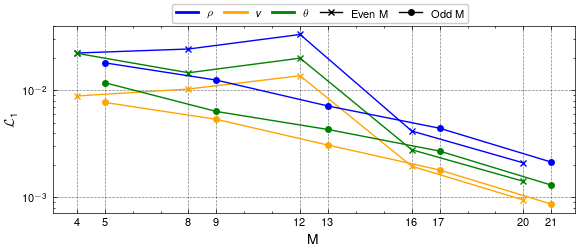

In [8]:
colors = ['blue', 'orange', 'green', 'red', 'purple']
markers = ['-x', '-o'] # even, odd

fig, axs = plt.subplots()
for key in ['even', 'odd']:
    Moments = Moments_even if key == 'even' else Moments_odd
    marker = markers[0] if key == 'even' else markers[1]
    axs.semilogy(Moments[:-1], rho_err[key]['L1'], marker, color=colors[0])
    axs.semilogy(Moments[:-1], v_err[key]['L1'], marker, color=colors[1])
    # axs.semilogy(Moments[:-1], p_err[key]['L1'], marker, color=colors[2])
    axs.semilogy(Moments[:-1], theta_err[key]['L1'], marker, color=colors[2])
axs.set_xticks(Moments_even[:-1] + Moments_odd[:-1])
axs.set_xlabel('M')
axs.set_ylabel('$\\mathcal{L}_1$')

property_elements = [Line2D([0], [0], color=colors[i], lw=2, label=closure) for i, closure in enumerate(['$\\rho$', '$v$', '$\\theta$'])]

order_element = [
    Line2D([0], [0], color='black', lw=1, label='Even M', marker=markers[0][-1]),
    Line2D([0], [0], color='black', lw=1, label='Odd M', marker=markers[1][-1])
]

# leg1 = fig.legend(
#     handles=property_elements, 
#     loc='upper center', 
#     bbox_to_anchor=(0.5, 1.14), 
#     ncol=3, 
#     # frameon=True,
#     columnspacing=1.0 # Adjust spacing between columns
# )

# leg2 = fig.legend(
#     handles=order_element, 
#     loc='upper center', 
#     bbox_to_anchor=(0.5, 1.05), 
#     ncol=2, 
#     # frameon=True,
#     columnspacing=1.0 # Adjust spacing between columns
# )
# fig.add_artist(leg1)

leg = fig.legend(
    handles=property_elements+order_element, 
    loc='upper center', 
    bbox_to_anchor=(0.55, 1.05), 
    ncol=5, 
    # frameon=True,
    columnspacing=1.0 # Adjust spacing between columns
)

fig.tight_layout()
fig.savefig('../out/Figures/ModelConvergence/ModelConvergence_L1.pdf', bbox_inches='tight')
fig.show()

# Riemann Problem

In [9]:
# update height
WIDTH = 6.0 
HEIGHT = 2.5 #5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
})

In [10]:
M = 8
closure_vec = ["Gram", "ExtGram", "Grad"]
Knudsen = [0.1, 1.0, 10.0]#!, 1.0] # last one doesn't matter, as zero_source
source = "relaxation_source"
T_end = 0.3
base_tree_level = 8
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

N = 1_000 # BGK
base_tree_level_bgk = 8
x_left_BGK = -5.0
x_right_BGK = 5.0
c_L = -6.0
c_R = 6.0

Plotting for Kn=10.0, source=relaxation_source
../out/Riemann1D/Moments/gram_solution_M8_closureGram_Kn10.0_sourcerelaxation_source_T_end0.3_rho_L7.0_rho_R1.0_v_L0.0_v_R0.0_theta_L1.0_theta_R1.0_base_tree_level8_polydeg1_cons.tsv


/tmp/ipykernel_9810/4159289718.py:64: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


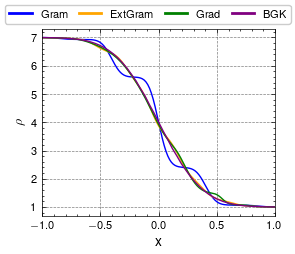

In [11]:

Kn = Knudsen[-1]

print(f"Plotting for Kn={Kn}, source={source}")

filename_moments = lambda closure: f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"
print(filename_moments("Gram"))
# if Kn != 0.1:
if Kn == 1.0 and source == "relaxation_source":
    data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_N{N}_Kn{Kn}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_ρ_v_p_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}.csv')
else:
    data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}_x_left{x_left_BGK}_x_right{x_right_BGK}_rho_v_p.csv')

colors = ['blue', 'orange', 'green', 'red', 'purple']

fig, axs = plt.subplots(figsize=(.5*WIDTH, HEIGHT))
for j, closure in enumerate(closure_vec):
    file = filename_moments(closure)
    x, u, _ = sol_final(file)
    rho = u[:, 0]
    v = u[:, 1] / rho
    p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
    theta = p / rho

    axs.plot(x, rho, color=colors[j])
    # axs[1].plot(x, v, color=colors[j])
    # axs[2].plot(x, theta, color=colors[j])
    # axs[2].plot(x, p, color=colors[j])
# for i in range(3):
#     for j, closure in enumerate(closure_vec):
#         file = filename_moments(closure)
#         x, u, _ = sol_final(file)
#         axs[i].plot(x, u[:, i], color=colors[j])

# BGK
# if Kn != 0.1:
x_bgk = data_bgk['x'].to_numpy()

rho_bgk = data_bgk['rho'].to_numpy()
axs.plot(x_bgk, rho_bgk, color=colors[4])

v_bgk = data_bgk['v'].to_numpy()
# axs.plot(x_bgk, v_bgk, color=colors[4])

p_bgk = data_bgk['p'].to_numpy()
theta_bgk = p_bgk / rho_bgk
# axs.plot(x_bgk, theta_bgk, color=colors[4])
axs.set_xlim(-1, 1)
axs.set_xlabel('x')
axs.set_ylabel('$\\rho$')
# axs.set_title(f'{labels[i]})', loc='left')

closure_elements = [Line2D([0], [0], color=colors[i], lw=2, label=closure_vec[i]) for i in range(len(closure_vec))] + [Line2D([0], [0], color=colors[4], lw=2, label='BGK')]
leg = fig.legend(
    handles=closure_elements, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.06), 
    ncol=4, 
    # frameon=True,
    columnspacing=1.0 # Adjust spacing between columns
)

fig.tight_layout()
fig.savefig(f'../out/Figures/ModelConvergence/Introduction_rho.pdf', bbox_inches='tight')
fig.show()

Plotting for Kn=0.1, source=relaxation_source
../out/Riemann1D/Moments/gram_solution_M8_closureGram_Kn0.1_sourcerelaxation_source_T_end0.3_rho_L7.0_rho_R1.0_v_L0.0_v_R0.0_theta_L1.0_theta_R1.0_base_tree_level8_polydeg1_cons.tsv


/tmp/ipykernel_9810/2762954482.py:86: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


Plotting for Kn=1.0, source=relaxation_source
../out/Riemann1D/Moments/gram_solution_M8_closureGram_Kn1.0_sourcerelaxation_source_T_end0.3_rho_L7.0_rho_R1.0_v_L0.0_v_R0.0_theta_L1.0_theta_R1.0_base_tree_level8_polydeg1_cons.tsv


/tmp/ipykernel_9810/2762954482.py:86: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


Plotting for Kn=10.0, source=relaxation_source
../out/Riemann1D/Moments/gram_solution_M8_closureGram_Kn10.0_sourcerelaxation_source_T_end0.3_rho_L7.0_rho_R1.0_v_L0.0_v_R0.0_theta_L1.0_theta_R1.0_base_tree_level8_polydeg1_cons.tsv


/tmp/ipykernel_9810/2762954482.py:86: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


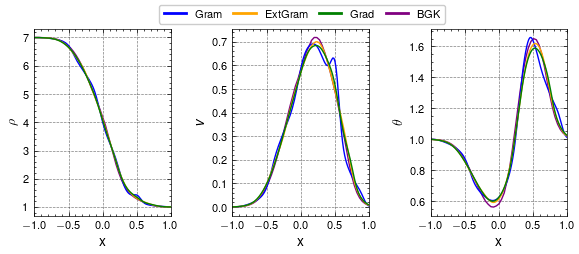

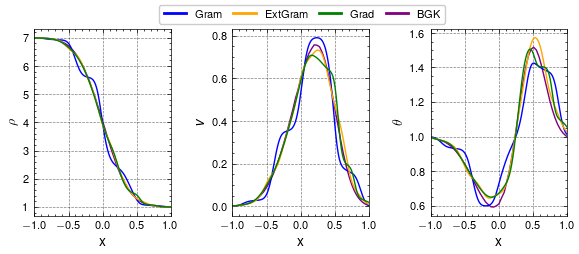

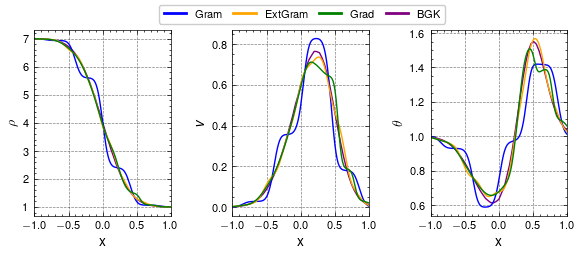

In [12]:
for i in range(len(Knudsen)):
    Kn = Knudsen[i]

    print(f"Plotting for Kn={Kn}, source={source}")

    filename_moments = lambda closure: f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"
    print(filename_moments("Gram"))
    # if Kn != 0.1:
    if Kn == 1.0 and source == "relaxation_source":
        data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_N{N}_Kn{Kn}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_ρ_v_p_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}.csv')
    else:
        data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}_x_left{x_left_BGK}_x_right{x_right_BGK}_rho_v_p.csv')

    colors = ['blue', 'orange', 'green', 'red', 'purple']

    fig, axs = plt.subplots(1, 3)
    [ax.set_xlim(-1, 1) for ax in axs]
    [ax.set_xlabel('x') for ax in axs]
    [ax.set_ylabel(label) for ax, label in zip(axs, ['$\\rho$', '$v$', '$\\theta$'])]

    # closure_elements = [Line2D([0], [0], color=colors[i], lw=2, label=closure_vec[i]) for i in range(len(closure_vec))] + [Line2D([0], [0], color=colors[3], lw=2, linestyle='--', label='ExtGram M=9')] + [Line2D([0], [0], color=colors[4], lw=2, label='BGK')]
    closure_elements = [
        Line2D([0], [0], color=colors[0], lw=2, label=closure_vec[0]),
        Line2D([0], [0], color=colors[1], lw=2, label=closure_vec[1]),
        # Line2D([0], [0], color=colors[3], lw=2, linestyle='--', label='ExtGram(M=9)'),
        Line2D([0], [0], color=colors[2], lw=2, label=closure_vec[2]),
        Line2D([0], [0], color=colors[4], lw=2, label='BGK')
    ]
    leg = fig.legend(
        handles=closure_elements, 
        loc='upper center', 
        bbox_to_anchor=(0.52, 1.06), 
        ncol=5, 
        # frameon=True,
        columnspacing=1.0 # Adjust spacing between columns
    )

    # BGK
    x_bgk = data_bgk['x'].to_numpy()

    rho_bgk = data_bgk['rho'].to_numpy()
    axs[0].plot(x_bgk, rho_bgk, color=colors[4])

    v_bgk = data_bgk['v'].to_numpy()
    axs[1].plot(x_bgk, v_bgk, color=colors[4])

    p_bgk = data_bgk['p'].to_numpy()
    theta_bgk = p_bgk / rho_bgk
    axs[2].plot(x_bgk, theta_bgk, color=colors[4])
    fig.tight_layout()
    fig.savefig(f'../out/Figures/ModelConvergence/CompareMethods_M8_Kn{Kn}_source{source}_BGK.pdf', bbox_inches='tight')
    for j, closure in enumerate(closure_vec):
        file = filename_moments(closure)
        x, u, _ = sol_final(file)
        rho = u[:, 0]
        v = u[:, 1] / rho
        p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
        theta = p / rho

        axs[0].plot(x, rho, color=colors[j])
        axs[1].plot(x, v, color=colors[j])
        axs[2].plot(x, theta, color=colors[j])

        fig.tight_layout()
        fig.savefig(f'../out/Figures/ModelConvergence/CompareMethods_M8_Kn{Kn}_source{source}_{j}.pdf', bbox_inches='tight')

        # if closure == "ExtGram":
        #     M_odd = 9
        #     filename_odd = f"../out/Riemann1D/Moments/gram_solution_M{M_odd}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        #     x, u, _ = sol_final(filename_odd)
        #     rho = u[:, 0]
        #     v = u[:, 1] / rho
        #     p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
        #     theta = p / rho

        #     axs[0].plot(x, rho, color=colors[3], linestyle='--')
        #     axs[1].plot(x, v, color=colors[3], linestyle='--')
        #     axs[2].plot(x, theta, color=colors[3], linestyle='--')

        #     fig.tight_layout()
        #     fig.savefig(f'../out/Figures/ModelConvergence/CompareMethods_M8_Kn{Kn}_source{source}_{j}_ExtGram.pdf', bbox_inches='tight')

    fig.tight_layout()
    fig.savefig(f'../out/Figures/ModelConvergence/CompareMethods_M8_Kn{Kn}_source{source}.pdf', bbox_inches='tight')
    fig.show()

### Collisionsless (Kn $= \infty$)

In [13]:
M = 8
closure_vec = ["Gram", "ExtGram", "Grad"]
Kn = 1.0 # doesn't matter physically, as zero_source, but used to store files
source = "zero_source"
T_end = 0.3
base_tree_level = 8
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

In [14]:
# Semi-analytical solution
class Maxwellian:
    def __init__(self, rho, v, theta):
        self.rho = rho
        self.v = v
        self.theta = theta

    def __call__(self, c):
        return self.rho / np.sqrt(2*np.pi*self.theta) * np.exp(-(c-self.v)**2 / (2*self.theta))

def f0(f_left, f_right, x, c):
    x_arr, c_arr = np.broadcast_arrays(np.asarray(x), np.asarray(c))
    return np.where(x_arr < 0, f_left(c_arr), f_right(c_arr))
    
def f(f_left, f_right, x, c, t):
    return f0(f_left, f_right, x - c*t, c)

maxwellian_L = Maxwellian(rho_L, v_L, theta_L)
maxwellian_R = Maxwellian(rho_R, v_R, theta_R)

In [15]:
Nx = np.linspace(-6, 6, 10_000)
Nc = np.linspace(-10, 10, 10_000)
T = 0.3
f_T = f(maxwellian_L, maxwellian_R, Nx, Nc[:, None], T)
rho_T = np.trapz(f_T, Nc, axis=0)
v_T = np.trapz(Nc[:, None] * f_T, Nc, axis=0) / rho_T
theta_T = np.trapz((Nc[:, None] - v_T)**2 * f_T, Nc, axis=0) / rho_T

/tmp/ipykernel_9810/3820276999.py:69: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


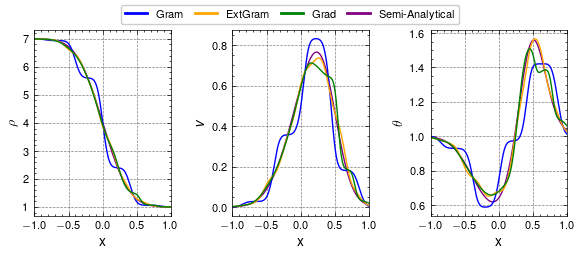

In [16]:
filename_moments = lambda closure: f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

colors = ['blue', 'orange', 'green', 'red', 'purple']

fig, axs = plt.subplots(1, 3)
[ax.set_xlim(-1, 1) for ax in axs]
[ax.set_xlabel('x') for ax in axs]
[ax.set_ylabel(label) for ax, label in zip(axs, ['$\\rho$', '$v$', '$\\theta$'])]
# [axs[i].set_title(f'{labels[i]})', loc='left') for i in range(3)]

# closure_elements = [Line2D([0], [0], color=colors[i], lw=2, label=closure_vec[i]) for i in range(len(closure_vec))] + [Line2D([0], [0], color=colors[4], lw=2, label='Semi-Analytical')]
closure_elements = [
        Line2D([0], [0], color=colors[0], lw=2, label=closure_vec[0]),
        Line2D([0], [0], color=colors[1], lw=2, label=closure_vec[1]),
        # Line2D([0], [0], color=colors[3], lw=2, linestyle='--', label='ExtGram(M=9)'),
        Line2D([0], [0], color=colors[2], lw=2, label=closure_vec[2]),
        Line2D([0], [0], color=colors[4], lw=2, label='Semi-Analytical')
    ]
leg = fig.legend(
    handles=closure_elements, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.06), 
    ncol=5, 
    # frameon=True,
    columnspacing=1.0 # Adjust spacing between columns
)

# semi-analytical
axs[0].plot(Nx, rho_T, color=colors[4])
axs[1].plot(Nx, v_T, color=colors[4])
axs[2].plot(Nx, theta_T, color=colors[4])
fig.tight_layout()
fig.savefig(f'../out/Figures/ModelConvergence/CompareMethods_M8_collisionless_ref.pdf', bbox_inches='tight')

for j, closure in enumerate(closure_vec):
    file = filename_moments(closure)
    x, u, _ = sol_final(file)
    rho = u[:, 0]
    v = u[:, 1] / rho
    p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
    theta = p / rho

    axs[0].plot(x, rho, color=colors[j])
    axs[1].plot(x, v, color=colors[j])
    axs[2].plot(x, theta, color=colors[j])

    fig.tight_layout()
    fig.savefig(f'../out/Figures/ModelConvergence/CompareMethods_M8_collisionless_{j}.pdf', bbox_inches='tight')

    # if closure == "ExtGram":
    #     M_odd = 9
    #     filename_odd = f"../out/Riemann1D/Moments/gram_solution_M{M_odd}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

    #     x, u, _ = sol_final(filename_odd)
    #     rho = u[:, 0]
    #     v = u[:, 1] / rho
    #     p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
    #     theta = p / rho

    #     axs[0].plot(x, rho, color=colors[3], linestyle='--')
    #     axs[1].plot(x, v, color=colors[3], linestyle='--')
    #     axs[2].plot(x, theta, color=colors[3], linestyle='--')

    #     fig.tight_layout()
    #     fig.savefig(f'../out/Figures/ModelConvergence/CompareMethods_M8_collisionless_{j}ExtGram.pdf', bbox_inches='tight')

fig.tight_layout()
fig.savefig(f'../out/Figures/ModelConvergence/CompareMethods_M8_collisionless.pdf', bbox_inches='tight')
fig.show()

# Rankine-Hugoniot

In [17]:
Moments = [4, 6, 8, 9]
closure = "Grad"
Kn = 1.0
source = "relaxation_source"
T_end = 25.0
base_tree_level = 10
polydeg = 1

# Initial condition parameters for the RH problem
Mach = np.array([1.4])#, 2.0])

rho_L = 1.0
rho_R = lambda Ma: (2*Ma**2) / (Ma**2 + 1)
v_L = lambda Ma: np.sqrt(3) * Ma
v_R = lambda Ma: np.sqrt(3) / 2 * (Ma**2 + 1) / Ma
theta_L = 1.0
theta_R = lambda Ma: (3*Ma**2 - 1) * (Ma**2 + 1) / (4 * Ma**2)

x_lower = -20.0
x_upper = 100.0

# BGK
N = 200
c_l = -6.0
c_u = 6.0

In [18]:
filename_moments = lambda closure, rho_L, rho_R, v_L, v_R, theta_L, theta_R: f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"
# Reference solution
reference_path = [f'../out/Riemann1D/ReferenceSolution/RankineHugoniot_Ma{str(Ma).split(".")[0]}_{str(Ma).split(".")[1]}.json' for Ma in Mach]
ref_data = []
for file_path in reference_path:
    with open(file_path, 'r') as file:
        data = json.load(file)

        # Extract the data and store it in a dictionary
        data_Ma = {}
        for data_point in data['datasetColl']:
            x, y = [], []
            for i in range(len(data_point['data'])):
                x.append(data_point['data'][i]['value'][0])
                y.append(data_point['data'][i]['value'][1])
            data_Ma[data_point['name']] = (np.array(x), np.array(y))
        ref_data.append(data_Ma)

/tmp/ipykernel_9810/4183225412.py:42: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


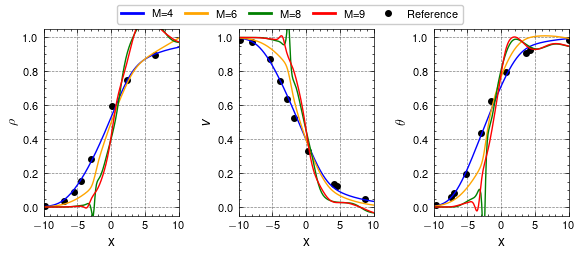

In [19]:
colors = ['blue', 'orange', 'green', 'red', 'purple']

for i, Ma in enumerate(Mach):
    fig, axs = plt.subplots(1, 3)
    for j, M in enumerate(Moments):
            file = filename_moments(closure, rho_L, rho_R(Ma), v_L(Ma), v_R(Ma), theta_L, theta_R(Ma))
            x, u, _ = sol_final(file)
            rho = u[:, 0]
            v = u[:, 1] / rho
            p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
            theta = p / rho

            axs[0].plot(x, (rho - rho_L) / (rho_R(Ma) - rho_L), color=colors[j])
            axs[1].plot(x, (v - v_R(Ma)) / (v_L(Ma) - v_R(Ma)), color=colors[j])
            axs[2].plot(x, (theta - theta_L) / (theta_R(Ma) - theta_L), color=colors[j])
        
    # Reference solution
    ref = ref_data[i]
    scatter_every = 10
    axs[0].scatter(ref['rho'][0][::scatter_every], ref['rho'][1][::scatter_every], color='black')
    axs[1].scatter(ref['v'][0][::scatter_every], ref['v'][1][::scatter_every], color='black')
    axs[2].scatter(ref['theta'][0][::scatter_every], ref['theta'][1][::scatter_every], color='black')

    [ax.set_xlim(-10, 10) for ax in axs]
    [ax.set_ylim(-0.05, 1.05) for ax in axs]
    [ax.set_xlabel('x') for ax in axs]
    [ax.set_ylabel(label) for ax, label in zip(axs, ['$\\rho$', '$v$', '$\\theta$'])]
    # [axs[i].set_title(f'{labels[i]})', loc='left') for i in range(3)]

    closure_elements = [Line2D([0], [0], color=colors[j], lw=2, label=f'M={M}') for j, M in enumerate(Moments)] + [Line2D([0], [0], color='black', marker='o', lw=0, label='Reference')]
    leg = fig.legend(
        handles=closure_elements, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 1.06), 
        ncol=5, 
        # frameon=True,
        columnspacing=1.0 # Adjust spacing between columns
    )

    fig.tight_layout()
    fig.savefig(f'../out/Figures/ModelConvergence/RankineHugoniot_Ma{Ma}_M{M}_Grad.pdf', bbox_inches='tight')
    fig.show()

In [20]:
Moments = [4, 8]
closure_vec = ["Gram", "ExtGram"]#!, "Grad"]
Kn = 1.0
source = "relaxation_source"
T_end = 25.0
base_tree_level = 10
polydeg = 1

# Initial condition parameters for the RH problem
Mach = np.array([1.4, 2.0])

rho_L = 1.0
rho_R = lambda Ma: (2*Ma**2) / (Ma**2 + 1)
v_L = lambda Ma: np.sqrt(3) * Ma
v_R = lambda Ma: np.sqrt(3) / 2 * (Ma**2 + 1) / Ma
theta_L = 1.0
theta_R = lambda Ma: (3*Ma**2 - 1) * (Ma**2 + 1) / (4 * Ma**2)

x_lower = -20.0
x_upper = 100.0

# BGK
N = 200
c_l = -6.0
c_u = 6.0

In [21]:
filename_moments = lambda closure, rho_L, rho_R, v_L, v_R, theta_L, theta_R: f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"
# Reference solution
reference_path = [f'../out/Riemann1D/ReferenceSolution/RankineHugoniot_Ma{str(Ma).split(".")[0]}_{str(Ma).split(".")[1]}.json' for Ma in Mach]
ref_data = []
for file_path in reference_path:
    with open(file_path, 'r') as file:
        data = json.load(file)

        # Extract the data and store it in a dictionary
        data_Ma = {}
        for data_point in data['datasetColl']:
            x, y = [], []
            for i in range(len(data_point['data'])):
                x.append(data_point['data'][i]['value'][0])
                y.append(data_point['data'][i]['value'][1])
            data_Ma[data_point['name']] = (np.array(x), np.array(y))
        ref_data.append(data_Ma)

/tmp/ipykernel_9810/1549413131.py:45: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


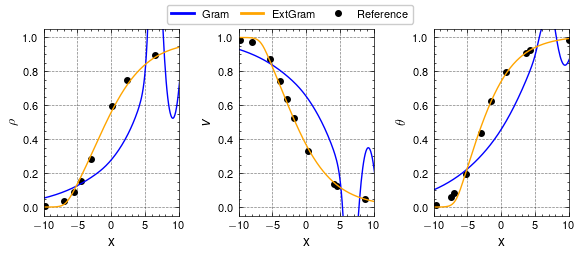

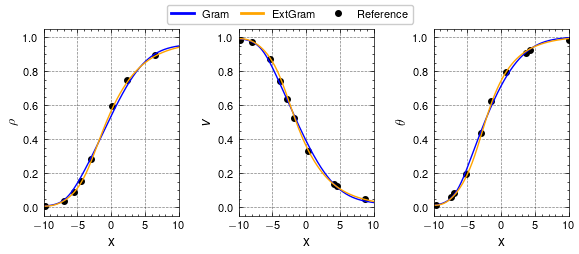

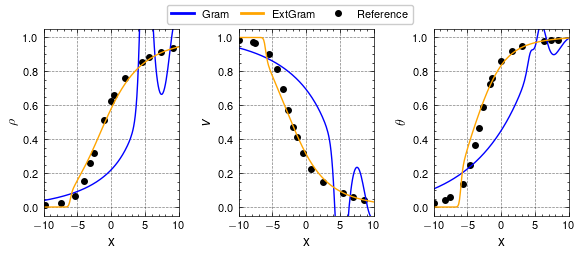

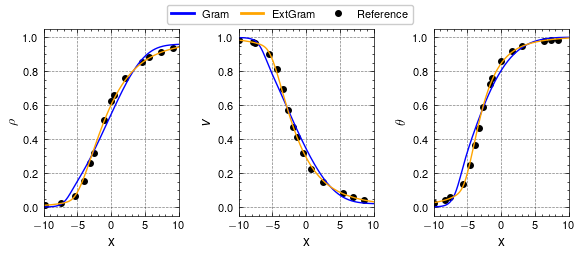

In [22]:
colors = ['blue', 'orange', 'green', 'red', 'purple']

for i, Ma in enumerate(Mach):
    for M in Moments:
        fig, axs = plt.subplots(1, 3)
        for j, closure in enumerate(closure_vec):
            if M == 8 and closure == "Grad":
                continue
            file = filename_moments(closure, rho_L, rho_R(Ma), v_L(Ma), v_R(Ma), theta_L, theta_R(Ma))
            x, u, _ = sol_final(file)
            rho = u[:, 0]
            v = u[:, 1] / rho
            p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
            theta = p / rho

            axs[0].plot(x, (rho - rho_L) / (rho_R(Ma) - rho_L), color=colors[j])
            axs[1].plot(x, (v - v_R(Ma)) / (v_L(Ma) - v_R(Ma)), color=colors[j])
            axs[2].plot(x, (theta - theta_L) / (theta_R(Ma) - theta_L), color=colors[j])
        
        # Reference solution
        ref = ref_data[i]
        scatter_every = 10
        axs[0].scatter(ref['rho'][0][::scatter_every], ref['rho'][1][::scatter_every], color='black')
        axs[1].scatter(ref['v'][0][::scatter_every], ref['v'][1][::scatter_every], color='black')
        axs[2].scatter(ref['theta'][0][::scatter_every], ref['theta'][1][::scatter_every], color='black')

        [ax.set_xlim(-10, 10) for ax in axs]
        [ax.set_ylim(-0.05, 1.05) for ax in axs]
        [ax.set_xlabel('x') for ax in axs]
        [ax.set_ylabel(label) for ax, label in zip(axs, ['$\\rho$', '$v$', '$\\theta$'])]
        # [axs[i].set_title(f'{labels[i]})', loc='left') for i in range(3)]

        closure_elements = [Line2D([0], [0], color=colors[i], lw=2, label=closure_vec[i]) for i in range(len(closure_vec))] + [Line2D([0], [0], color='black', marker='o', lw=0, label='Reference')]
        leg = fig.legend(
            handles=closure_elements, 
            loc='upper center', 
            bbox_to_anchor=(0.5, 1.06), 
            ncol=4, 
            # frameon=True,
            columnspacing=1.0 # Adjust spacing between columns
        )

        fig.tight_layout()
        fig.savefig(f'../out/Figures/ModelConvergence/RankineHugoniot_Ma{Ma}_M{M}.pdf', bbox_inches='tight')
        fig.show()

# Convergence towards Kinetic Equation

In [24]:
# === Usage Example ===
M_vector = [4, 8, 12, 16, 20, 24]
closure = "ExtGram"
Kn = 1.0
source_string = "zero_source"
T_end = 0.3
base_tree_level = 6
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0
filename = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}.tsv"
data = read_solution_file(filename)

# Build time → timestep mapping
times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
timesteps = np.array(sorted(data.keys()))

time_query = 21 # last time step
sol = interpolate_solution(data, time_query, times, timesteps)
x, u, t = sol["x"], sol["u"], sol["t"]

In [25]:
# Maxwellian helper
class Maxwellian:
    def __init__(self, rho, v, theta):
        self.rho = rho
        self.v = v
        self.theta = theta

    def __call__(self, c):
        return self.rho / np.sqrt(2*np.pi*self.theta) * np.exp(-(c-self.v)**2 / (2*self.theta))

def f0(f_left, f_right, x, c):
    x_arr, c_arr = np.broadcast_arrays(np.asarray(x), np.asarray(c))
    return np.where(x_arr < 0, f_left(c_arr), f_right(c_arr))
    
def f(f_left, f_right, x, c, t):
    return f0(f_left, f_right, x - c*t, c)

In [26]:
def convergence_moments(M):
    filename = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}.tsv"
    data = read_solution_file(filename)

    # Build time → timestep mapping
    times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
    timesteps = np.array(sorted(data.keys()))

    time_query = 21 # last time step
    sol = interpolate_solution(data, time_query, times, timesteps)
    x, u, t = sol["x"], sol["u"], sol["t"]

    # Construct BGK solution
    x_BGK = np.linspace(-6, 6, 10_000)
    c_BGK = np.linspace(-10, 10, 10_000)
    maxwellian_L = Maxwellian(rho_L, v_L, theta_L)
    maxwellian_R = Maxwellian(rho_R, v_R, theta_R)
    f_T = f(maxwellian_L, maxwellian_R, x_BGK, c_BGK[:, None], T_end)

    L1_ = []
    for i in range(M):
        u_BGK = np.trapz(c_BGK[:, None]**i * f_T, c_BGK, axis=0)
        u_BGK_interp1D = interp1d(x_BGK, u_BGK, kind='linear')
        u_BGK_projected = u_BGK_interp1D(x)
        u_ExtGramian = u[:,i]
        L1_.append(
            np.linalg.norm(u_ExtGramian - u_BGK_projected, 1) / np.linalg.norm(u_BGK_projected, 1)
        )
        
    moments_ = np.linspace(0, M-1, M, dtype=int)
    fig, axs = plt.subplots(2)
    axs[0].semilogy(moments_[::2], L1_[::2], '-o', color='blue')
    axs[0].set_xticks(moments_[::2])

    axs[1].semilogy(moments_[1:][::2], L1_[1:][::2], '-o', color='blue')
    axs[1].set_xticks(moments_[1:][::2])

    [ax.grid() for ax in axs]
    [ax.set_xlabel('Moment') for ax in axs]
    [ax.set_ylabel('$\\mathcal{L}_1$') for ax in axs]

    fig.tight_layout()
    return fig, axs, moments_, L1_

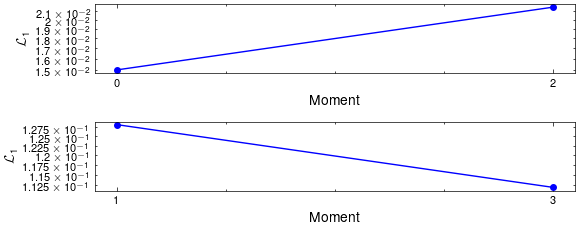

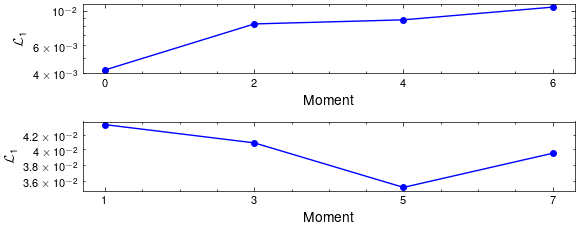

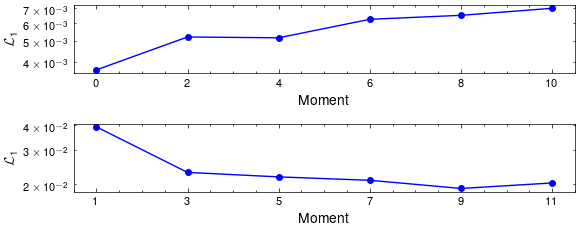

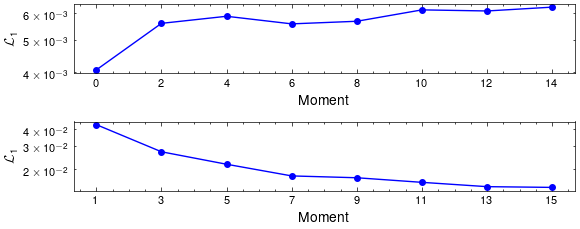

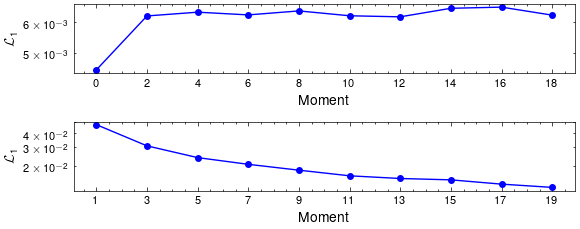

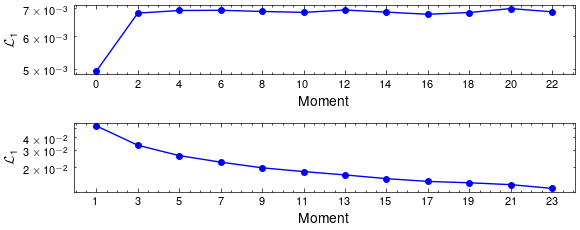

In [27]:
moments, L1 = [], []
M_vector = [4, 8, 12, 16, 20, 24]
for M in M_vector:
    fig, axs, moments_, L1_ = convergence_moments(M)
    # fig.show()

    moments.append(moments_)
    L1.append(L1_)

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_99056/2768685141.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


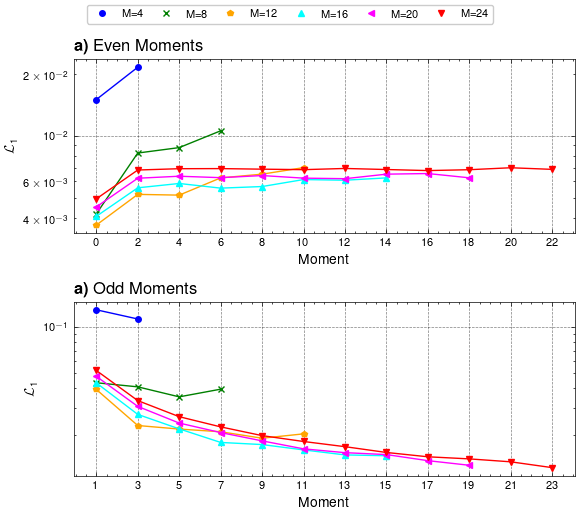

In [28]:
colors = ['blue', 'green', 'orange', 'cyan', 'magenta', 'red']
marker = ['-o', '-x', '-p', '-^', '-<', '-v']
marker_legend = ['o', 'x', 'p', '^', '<', 'v']

fig, axs = plt.subplots(2, figsize=(6.0, 5.0))
[axs[0].semilogy(moments[i][::2], L1[i][::2], marker[i], color=colors[i]) for i, M in enumerate(M_vector)]
axs[0].set_xticks(moments[-1][::2])
axs[0].set_title('\\textbf{a)} Even Moments', loc='left')

[axs[1].semilogy(moments[i][1:][::2], L1[i][1:][::2], marker[i], color=colors[i]) for i, M in enumerate(M_vector)]
axs[1].set_xticks(moments[-1][1:][::2])
axs[1].set_title('\\textbf{a)} Odd Moments', loc='left')

[ax.set_xlabel('Moment') for ax in axs]
[ax.set_ylabel('$\\mathcal{L}_1$') for ax in axs]

moment_elements = [Line2D([0], [0], marker=marker_legend[i], color=colors[i], label=f'M={M}', linestyle='') for i, M in enumerate(M_vector)]
leg = fig.legend(
    handles=moment_elements, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.05), 
    ncol=6, 
    # frameon=True,
    columnspacing=1.0 # Adjust spacing between columns
)

fig.tight_layout()
fig.savefig("../out/Figures/ModelConvergence/MomentConvergenceToBGK.pdf")
fig.show()

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_99056/4092655581.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


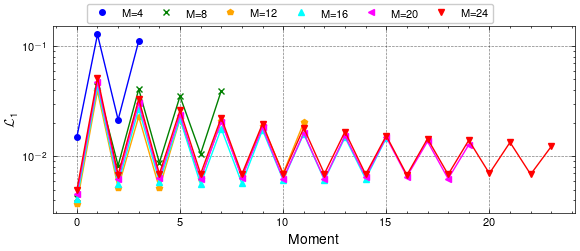

In [29]:
fig, axs = plt.subplots()
[axs.semilogy(moments[i], L1[i], marker[i], color=colors[i]) for i, M in enumerate(M_vector)]
axs.set_xlabel('Moment')
axs.set_ylabel('$\\mathcal{L}_1$')

moment_elements = [Line2D([0], [0], marker=marker_legend[i], color=colors[i], label=f'M={M}', linestyle='') for i, M in enumerate(M_vector)]
leg = fig.legend(
    handles=moment_elements, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.05), 
    ncol=6, 
    # frameon=True,
    columnspacing=1.0 # Adjust spacing between columns
)

fig.tight_layout()
fig.savefig("../out/Figures/ModelConvergence/MomentConvergenceToBGK_Compact.pdf")
fig.show()